In [ ]:
pip install torch torchvision matplotlib scikit-learn tqdm

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score
from tqdm import tqdm

# 3. Define the computational device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 4. Define a helper function to display a grid of images
def imshow(img_tensor, title=None):
    # Unnormalize images if they were normalized (e.g., for Fashion-MNIST or ImageNet pre-trained models)
    # For Fashion-MNIST, images are typically grayscale and not normalized to a specific range like ImageNet
    # If using torchvision.transforms.Normalize, you'd need to reverse it here.
    # For this task, we assume images are already in a viewable range or will be scaled by matplotlib.
    npimg = img_tensor.numpy() # Convert tensor to numpy array
    plt.imshow(np.transpose(npimg, (1, 2, 0))) # Rearrange dimensions for matplotlib (C, H, W) -> (H, W, C)
    if title: plt.title(title)
    plt.axis('off') # Hide axes
    plt.show()

def display_images_grid(images, title=None, num_images=16):
    fig = plt.figure(figsize=(8, 8))
    for i in range(num_images):
        ax = fig.add_subplot(int(np.sqrt(num_images)), int(np.sqrt(num_images)), i + 1, xticks=[], yticks=[])
        # If images are grayscale (1 channel), convert to 3 channels for imshow or handle appropriately
        if images.shape[1] == 1:
            ax.imshow(images[i].squeeze(), cmap='gray')
        else:
            # For color images (e.g., from GANs), assuming CxHxW format
            ax.imshow(np.transpose(images[i].cpu().detach().numpy(), (1, 2, 0)))
    if title: fig.suptitle(title)
    plt.show()

# 5. Define a helper function to plot training loss and accuracy curves
def plot_metrics(train_losses, train_accuracies, val_losses=None, val_accuracies=None, title='Training and Validation Metrics'):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b', label='Training loss')
    if val_losses: plt.plot(epochs, val_losses, 'r', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'b', label='Training accuracy')
    if val_accuracies: plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.suptitle(title, y=1.02, fontsize=16)
    plt.show()

print("Libraries imported, device set, and helper functions defined.")

Using device: cpu
Libraries imported, device set, and helper functions defined.


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Normalize to [-1, 1] range for grayscale images
])

print("Data transformations defined.")

Data transformations defined.


In [ ]:
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 64
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Fashion-MNIST training dataset loaded with {len(train_dataset)} samples.")
print(f"Fashion-MNIST test dataset loaded with {len(test_dataset)} samples.")
print(f"Training DataLoader created with batch size {batch_size}.")
print(f"Test DataLoader created with batch size {batch_size}.")

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 306kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.53MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.1MB/s]

Fashion-MNIST training dataset loaded with 60000 samples.
Fashion-MNIST test dataset loaded with 10000 samples.
Training DataLoader created with batch size 64.
Test DataLoader created with batch size 64.


Labels: Pullover Sandal T-shirt/top Ankle Boot


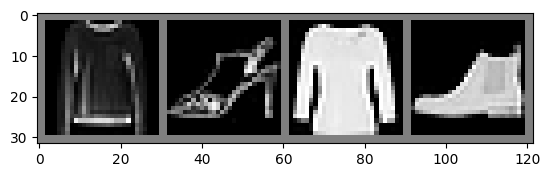

Sample images from Fashion-MNIST dataset displayed.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Define class names for Fashion-MNIST
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')

# Function to unnormalize and display images
def imshow_unnormalized(img):
    img = img / 2 + 0.5  # Unnormalize: reverse the Normalize((0.5,), (0.5,)) transform
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Display images
print('Labels:', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))
imshow_unnormalized(torchvision.utils.make_grid(images[:4]))

print("Sample images from Fashion-MNIST dataset displayed.")

In [ ]:
class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            # First Convolutional Block
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: 32x14x14

            # Second Convolutional Block
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  # Output: 64x7x7
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128), # Flattened output from conv layers
            nn.ReLU(),
            nn.Linear(128, 10)         # Output for 10 classes
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1) # Flatten the tensor
        x = self.fc_layers(x)
        return x

print("CustomCNN model architecture defined.")

CustomCNN model architecture defined.


In [ ]:
model = CustomCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("CustomCNN model instantiated and moved to device.")
print("Loss function and optimizer defined.")

CustomCNN model instantiated and moved to device.
Loss function and optimizer defined.


In [ ]:
def train_model(model, criterion, optimizer, train_loader, test_loader, num_epochs=10):
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        for i, (inputs, labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} Training")):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_accuracy = 100 * correct_train / total_train
        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_accuracy)

        # Validation
        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for inputs, labels in tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} Validation"):
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = running_val_loss / len(test_loader.dataset)
        epoch_val_accuracy = 100 * correct_val / total_val
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_accuracy)

        print(f'Epoch {epoch+1}/{num_epochs}: Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.2f}%, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.2f}%')

    print("Finished Training")
    return train_losses, train_accuracies, val_losses, val_accuracies

print("Training function 'train_model' defined.")

Training function 'train_model' defined.


In [ ]:
num_epochs_custom_cnn = 10
custom_cnn_train_losses, custom_cnn_train_accuracies, custom_cnn_val_losses, custom_cnn_val_accuracies = \
    train_model(model, criterion, optimizer, train_loader, test_loader, num_epochs=num_epochs_custom_cnn)

print("Custom CNN training complete. Metrics stored.")

Epoch 1/10 Validation: 100%|██████████| 157/157 [00:06<00:00, 22.96it/s]


Epoch 1/10: Train Loss: 0.4426, Train Acc: 84.07%, Val Loss: 0.3449, Val Acc: 87.25%


Epoch 2/10 Validation: 100%|██████████| 157/157 [00:06<00:00, 25.05it/s]


Epoch 2/10: Train Loss: 0.2833, Train Acc: 89.73%, Val Loss: 0.2741, Val Acc: 90.04%


Epoch 3/10 Validation: 100%|██████████| 157/157 [00:07<00:00, 21.77it/s]


...

Epoch 8/10: Train Loss: 0.1190, Train Acc: 95.62%, Val Loss: 0.2634, Val Acc: 91.27%


Epoch 9/10 Validation: 100%|██████████| 157/157 [00:07<00:00, 19.88it/s]


Epoch 9/10: Train Loss: 0.1008, Train Acc: 96.27%, Val Loss: 0.2666, Val Acc: 91.87%


Epoch 10/10 Validation: 100%|██████████| 157/157 [00:07<00:00, 21.52it/s]

Epoch 10/10: Train Loss: 0.0873, Train Acc: 96.75%, Val Loss: 0.2617, Val Acc: 92.05%
Finished Training
Custom CNN training complete. Metrics stored.


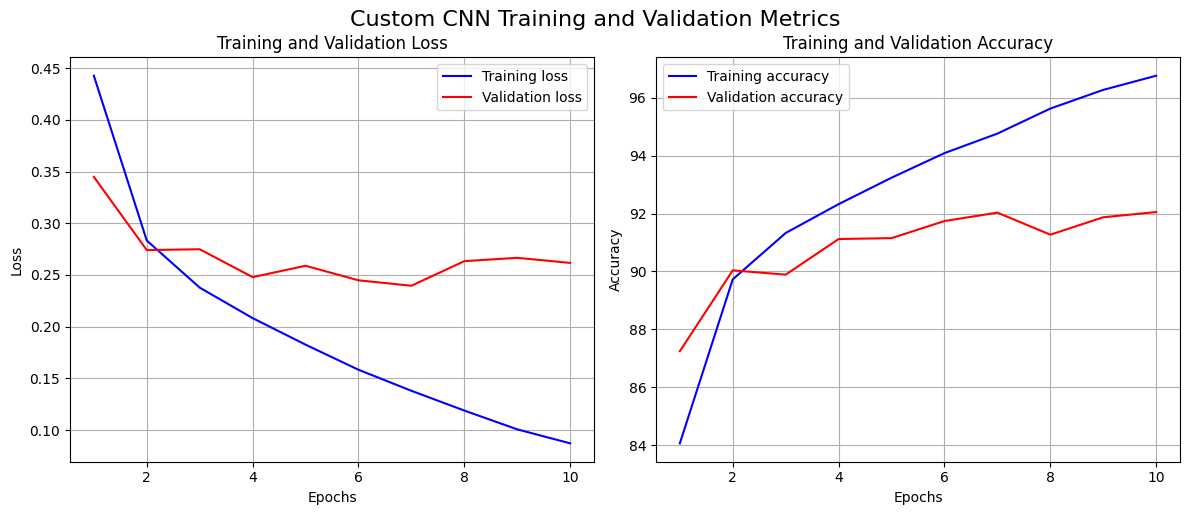

Custom CNN training and validation metrics plotted.


In [ ]:
plot_metrics(custom_cnn_train_losses, custom_cnn_train_accuracies, custom_cnn_val_losses, custom_cnn_val_accuracies, title='Custom CNN Training and Validation Metrics')
print("Custom CNN training and validation metrics plotted.")

In [ ]:
def evaluate_model(model, criterion, data_loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in tqdm(data_loader, desc="Evaluating Model"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0);
            correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(data_loader.dataset)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

test_loss_custom_cnn, test_accuracy_custom_cnn = evaluate_model(model, criterion, test_loader)
print(f'Custom CNN Final Test Loss: {test_loss_custom_cnn:.4f}, Test Accuracy: {test_accuracy_custom_cnn:.2f}%')

print("Custom CNN evaluation complete.")

Evaluating Model: 100%|██████████| 157/157 [00:08<00:00, 18.71it/s]

Custom CNN Final Test Loss: 0.2617, Test Accuracy: 92.05%
Custom CNN evaluation complete.


In [ ]:
print("\nCustom CNN Training Metrics:")
for i in range(len(custom_cnn_train_losses)):
    epoch = i + 1
    train_loss = custom_cnn_train_losses[i]
    train_accuracy = custom_cnn_train_accuracies[i]
    print(f"Epoch {epoch}: Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%")



Custom CNN Training Metrics:
Epoch 1: Train Loss: 0.4426, Train Accuracy: 84.07%
Epoch 2: Train Loss: 0.2833, Train Accuracy: 89.73%
Epoch 3: Train Loss: 0.2378, Train Accuracy: 91.33%
Epoch 4: Train Loss: 0.2083, Train Accuracy: 92.32%
Epoch 5: Train Loss: 0.1827, Train Accuracy: 93.23%
Epoch 6: Train Loss: 0.1584, Train Accuracy: 94.08%
Epoch 7: Train Loss: 0.1381, Train Accuracy: 94.76%
Epoch 8: Train Loss: 0.1190, Train Accuracy: 95.62%
Epoch 9: Train Loss: 0.1008, Train Accuracy: 96.27%
Epoch 10: Train Loss: 0.0873, Train Accuracy: 96.75%


In [ ]:
print("\nCustom CNN Validation Metrics:")
for i in range(len(custom_cnn_val_losses)):
    epoch = i + 1
    val_loss = custom_cnn_val_losses[i]
    val_accuracy = custom_cnn_val_accuracies[i]
    print(f"Epoch {epoch}: Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")


Custom CNN Validation Metrics:
Epoch 1: Val Loss: 0.3449, Val Accuracy: 87.25%
Epoch 2: Val Loss: 0.2741, Val Accuracy: 90.04%
Epoch 3: Val Loss: 0.2749, Val Accuracy: 89.89%
Epoch 4: Val Loss: 0.2479, Val Accuracy: 91.12%
Epoch 5: Val Loss: 0.2589, Val Accuracy: 91.15%
Epoch 6: Val Loss: 0.2448, Val Accuracy: 91.74%
Epoch 7: Val Loss: 0.2396, Val Accuracy: 92.03%
Epoch 8: Val Loss: 0.2634, Val Accuracy: 91.27%
Epoch 9: Val Loss: 0.2666, Val Accuracy: 91.87%
Epoch 10: Val Loss: 0.2617, Val Accuracy: 92.05%


In [ ]:
print(f"\nCustom CNN Final Test Loss: {test_loss_custom_cnn:.4f}")
print(f"Custom CNN Final Test Accuracy: {test_accuracy_custom_cnn:.2f}%")
print("\nSummary of Custom CNN model performance complete.")


Custom CNN Final Test Loss: 0.2617
Custom CNN Final Test Accuracy: 92.05%

Summary of Custom CNN model performance complete.


In [ ]:
import torchvision.models as models

# 1. Load a pre-trained ResNet18 model
resnet_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 2. Modify the first convolutional layer for 1-channel images (Fashion-MNIST is grayscale)
# Original conv1: Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
resnet_model.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)

# 3. Replace the final fully connected layer to output 10 classes
# Get the number of input features for the original fully connected layer
num_ftrs = resnet_model.fc.in_features
# Replace the classifier with a new one for 10 output classes
resnet_model.fc = nn.Linear(num_ftrs, 10)

# 4. Move the modified ResNet18 model to the device
resnet_model = resnet_model.to(device)

print("Pre-trained ResNet18 model loaded, modified for Fashion-MNIST, and moved to device.")

Pre-trained ResNet18 model loaded, modified for Fashion-MNIST, and moved to device.


In [ ]:
import torch.nn as nn
import torch.optim as optim

# 1. Freeze all parameters in the network
for param in resnet_model.parameters():
    param.requires_grad = False

# 2. Unfreeze the parameters of the final fully connected layer
for param in resnet_model.fc.parameters():
    param.requires_grad = True

# 3. Define the loss function
criterion_resnet = nn.CrossEntropyLoss()

# 4. Initialize the Adam optimizer with only the trainable parameters
optimizer_resnet = optim.Adam(filter(lambda p: p.requires_grad, resnet_model.parameters()), lr=0.001)

print("ResNet18 base layers frozen. Only the final FC layer is trainable.")
print("Loss function (CrossEntropyLoss) and Adam optimizer defined for ResNet18.")

ResNet18 base layers frozen. Only the final FC layer is trainable.
Loss function (CrossEntropyLoss) and Adam optimizer defined for ResNet18.


In [ ]:
num_epochs_resnet = 4
resnet_train_losses, resnet_train_accuracies, resnet_val_losses, resnet_val_accuracies = \
    train_model(resnet_model, criterion_resnet, optimizer_resnet, train_loader, test_loader, num_epochs=num_epochs_resnet)

print("ResNet18 model training complete. Metrics stored.")

Epoch 1/4 Validation: 100%|██████████| 157/157 [00:27<00:00,  5.69it/s]


Epoch 1/4: Train Loss: 1.1194, Train Acc: 61.29%, Val Loss: 0.9639, Val Acc: 66.84%


Epoch 2/4 Validation: 100%|██████████| 157/157 [00:26<00:00,  5.95it/s]


Epoch 2/4: Train Loss: 0.9746, Train Acc: 65.53%, Val Loss: 0.9546, Val Acc: 66.62%


Epoch 3/4 Validation: 100%|██████████| 157/157 [00:25<00:00,  6.07it/s]


Epoch 3/4: Train Loss: 0.9545, Train Acc: 66.17%, Val Loss: 0.9290, Val Acc: 67.54%


Epoch 4/4 Validation: 100%|██████████| 157/157 [00:26<00:00,  5.95it/s]

Epoch 4/4: Train Loss: 0.9467, Train Acc: 66.53%, Val Loss: 0.9350, Val Acc: 67.29%
Finished Training
ResNet18 model training complete. Metrics stored.


In [ ]:
test_loss_resnet, test_accuracy_resnet = evaluate_model(resnet_model, criterion_resnet, test_loader)
print(f'ResNet18 Final Test Loss: {test_loss_resnet:.4f}, Test Accuracy: {test_accuracy_resnet:.2f}%')

print("ResNet18 evaluation complete.")

Evaluating Model: 100%|██████████| 157/157 [00:27<00:00,  5.75it/s]

ResNet18 Final Test Loss: 0.9350, Test Accuracy: 67.29%
ResNet18 evaluation complete.


In [ ]:
print("\nResNet18 Training Metrics:")
for i in range(len(resnet_train_losses)):
    epoch = i + 1
    train_loss = resnet_train_losses[i]
    train_accuracy = resnet_train_accuracies[i]
    print(f"Epoch {epoch}: Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%")


ResNet18 Training Metrics:
Epoch 1: Train Loss: 1.1194, Train Accuracy: 61.29%
Epoch 2: Train Loss: 0.9746, Train Accuracy: 65.53%
Epoch 3: Train Loss: 0.9545, Train Accuracy: 66.17%
Epoch 4: Train Loss: 0.9467, Train Accuracy: 66.53%


In [ ]:
print("\nResNet18 Validation Metrics:")
for i in range(len(resnet_val_losses)):
    epoch = i + 1
    val_loss = resnet_val_losses[i]
    val_accuracy = resnet_val_accuracies[i]
    print(f"Epoch {epoch}: Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")


ResNet18 Validation Metrics:
Epoch 1: Val Loss: 0.9639, Val Accuracy: 66.84%
Epoch 2: Val Loss: 0.9546, Val Accuracy: 66.62%
Epoch 3: Val Loss: 0.9290, Val Accuracy: 67.54%
Epoch 4: Val Loss: 0.9350, Val Accuracy: 67.29%


In [ ]:
print(f"\nResNet18 Final Test Loss: {test_loss_resnet:.4f}")
print(f"ResNet18 Final Test Accuracy: {test_accuracy_resnet:.2f}%")
print("\nSummary of ResNet18 model performance complete.")


ResNet18 Final Test Loss: 0.9350
ResNet18 Final Test Accuracy: 67.29%

Summary of ResNet18 model performance complete.


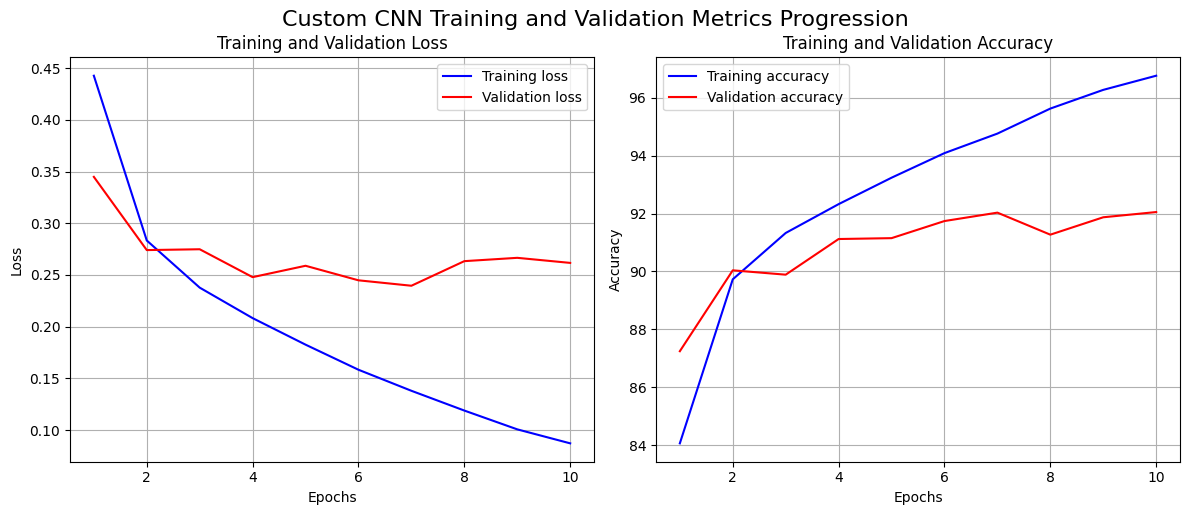

Custom CNN training and validation metrics plot generated.


In [ ]:
plot_metrics(custom_cnn_train_losses, custom_cnn_train_accuracies, custom_cnn_val_losses, custom_cnn_val_accuracies, title='Custom CNN Training and Validation Metrics Progression')
print("Custom CNN training and validation metrics plot generated.")

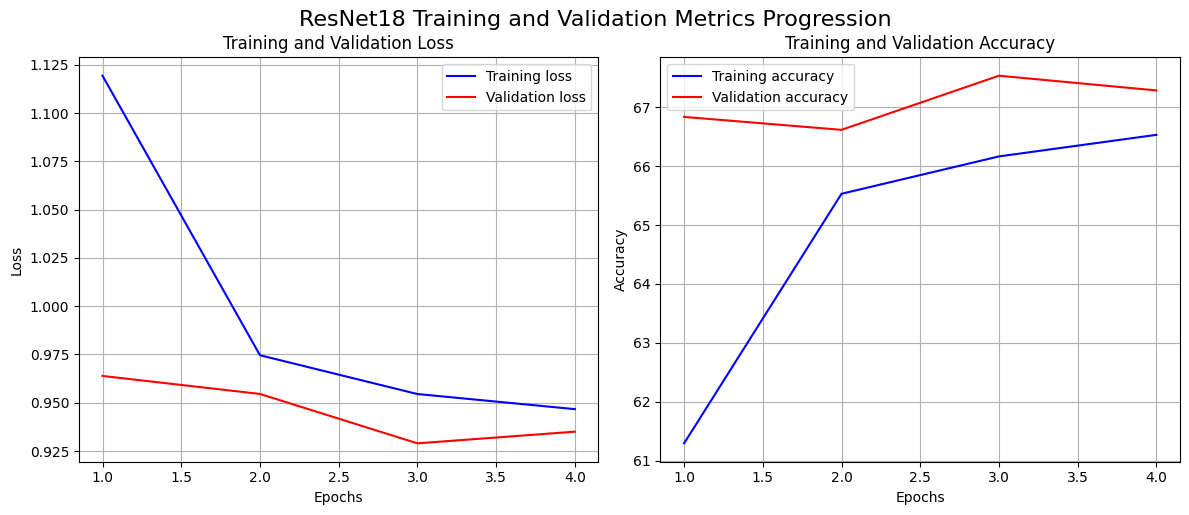

ResNet18 training and validation metrics plot generated.


In [ ]:
plot_metrics(resnet_train_losses, resnet_train_accuracies, resnet_val_losses, resnet_val_accuracies, title='ResNet18 Training and Validation Metrics Progression')
print("ResNet18 training and validation metrics plot generated.")

In [ ]:
import torchtext
from torchtext.data.utils import get_tokenizer
from collections import Counter

# 1. Define a tokenizer function
tokenizer = get_tokenizer('basic_english')

print("torchtext libraries imported and basic_english tokenizer defined.")

ModuleNotFoundError: No module named 'torchtext'

In [ ]:
!pip install torchtext

print("torchtext installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 514.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 768.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 591.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288

torchtext installed successfully.


In [ ]:
!pip install tensorflow

print("TensorFlow installed successfully.")

TensorFlow installed successfully.


In [10]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Load the IMDB dataset with vocabulary limit
vocabulary_size = 10000
(X_train_imdb, y_train_imdb), (X_test_imdb, y_test_imdb) = imdb.load_data(num_words=vocabulary_size)

print(f"Original training sequences shape: {len(X_train_imdb)}")
print(f"Original testing sequences shape: {len(X_test_imdb)}")

# 2. Pad/truncate sequences to a fixed length
max_sequence_length = 200
X_train_imdb = pad_sequences(X_train_imdb, maxlen=max_sequence_length)
X_test_imdb = pad_sequences(X_test_imdb, maxlen=max_sequence_length)

# 3. Print shapes of preprocessed data
print(f"Preprocessed training data shape: {X_train_imdb.shape}")
print(f"Preprocessed testing data shape: {X_test_imdb.shape}")

print("IMDB dataset loaded and preprocessed.")

Original training sequences shape: 25000
Original testing sequences shape: 25000
Preprocessed training data shape: (25000, 200)
Preprocessed testing data shape: (25000, 200)
IMDB dataset loaded and preprocessed.


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Re-define parameters from previous step to ensure scope
vocabulary_size = 10000
max_sequence_length = 200

# 2. Define the Simple RNN model using tf.keras.Sequential
rnn_model = Sequential([
    # 3. Add an Embedding layer
    Embedding(input_dim=vocabulary_size, output_dim=128),
    # 4. Add a SimpleRNN layer
    SimpleRNN(128),
    # 5. Add a Dense output layer with sigmoid activation for binary classification
    Dense(1, activation='sigmoid')
])

# Explicitly build the model to see the parameter summary
rnn_model.build(input_shape=(None, max_sequence_length))

# 6. Print a summary of the model architecture
rnn_model.summary()

print("Simple RNN model defined and summary printed.")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,025 (5.01 MB)

 Trainable params: 1,313,025 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

Simple RNN model defined and summary printed.


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Re-define parameters from previous step to ensure scope
vocabulary_size = 10000
max_sequence_length = 200

# 2. Create a Sequential model named lstm_model
lstm_model = Sequential([
    # 3. Add an Embedding layer
    Embedding(input_dim=vocabulary_size, output_dim=128),
    # 4. Add an LSTM layer
    LSTM(128),
    # 5. Add a Dense output layer with sigmoid activation for binary classification
    Dense(1, activation='sigmoid')
])

# 6. Explicitly build the model to see the parameter summary
lstm_model.build(input_shape=(None, max_sequence_length))

# 7. Print a summary of the model architecture
lstm_model.summary()

print("LSTM model defined and summary printed.")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,411,713 (5.39 MB)

 Trainable params: 1,411,713 (5.39 MB)

 Non-trainable params: 0 (0.00 B)

LSTM model defined and summary printed.


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense

# Re-define parameters from previous step to ensure scope
vocabulary_size = 10000
max_sequence_length = 200

# 2. Create a Sequential model named gru_model
gru_model = Sequential([
    # 3. Add an Embedding layer
    Embedding(input_dim=vocabulary_size, output_dim=128),
    # 4. Add a GRU layer
    GRU(128),
    # 5. Add a Dense output layer with sigmoid activation for binary classification
    Dense(1, activation='sigmoid')
])

# 6. Explicitly build the model to see the parameter summary
gru_model.build(input_shape=(None, max_sequence_length))

# 7. Print a summary of the model architecture
gru_model.summary()

print("GRU model defined and summary printed.")

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,379,201 (5.26 MB)

 Trainable params: 1,379,201 (5.26 MB)

 Non-trainable params: 0 (0.00 B)

GRU model defined and summary printed.


In [7]:
rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Simple RNN model compiled.")

Simple RNN model compiled.


In [11]:
history_rnn = rnn_model.fit(X_train_imdb, y_train_imdb, epochs=5, batch_size=32, validation_data=(X_test_imdb, y_test_imdb))

print("Simple RNN model training complete. Training history stored.")

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - accuracy: 0.6339 - loss: 0.6218 - val_accuracy: 0.6292 - val_loss: 0.6357
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.7749 - loss: 0.4763 - val_accuracy: 0.7968 - val_loss: 0.4575
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.8334 - loss: 0.3879 - val_accuracy: 0.8076 - val_loss: 0.4500
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.8477 - loss: 0.3536 - val_accuracy: 0.7822 - val_loss: 0.4891
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.8538 - loss: 0.3484 - val_accuracy: 0.8112 - val_loss: 0.4767
Simple RNN model training complete. Training history stored.


In [12]:
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("LSTM model compiled.")

LSTM model compiled.


In [13]:
history_lstm = lstm_model.fit(X_train_imdb, y_train_imdb, epochs=5, batch_size=32, validation_data=(X_test_imdb, y_test_imdb))

print("LSTM model training complete. Training history stored.")

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.7910 - loss: 0.4483 - val_accuracy: 0.8460 - val_loss: 0.3612
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.8826 - loss: 0.2881 - val_accuracy: 0.8638 - val_loss: 0.3465
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.9182 - loss: 0.2093 - val_accuracy: 0.8491 - val_loss: 0.3598
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.9456 - loss: 0.1513 - val_accuracy: 0.8619 - val_loss: 0.3847
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.9609 - loss: 0.1100 - val_accuracy: 0.8521 - val_loss: 0.4256
LSTM model training complete. Training history stored.


In [14]:
gru_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("GRU model compiled.")

GRU model compiled.


In [15]:
history_gru = gru_model.fit(X_train_imdb, y_train_imdb, epochs=5, batch_size=32, validation_data=(X_test_imdb, y_test_imdb))

print("GRU model training complete. Training history stored.")

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.7908 - loss: 0.4382 - val_accuracy: 0.8689 - val_loss: 0.3183
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9096 - loss: 0.2289 - val_accuracy: 0.8824 - val_loss: 0.2817
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9512 - loss: 0.1369 - val_accuracy: 0.8667 - val_loss: 0.3684
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9730 - loss: 0.0784 - val_accuracy: 0.8700 - val_loss: 0.4441
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9863 - loss: 0.0425 - val_accuracy: 0.8681 - val_loss: 0.5082
GRU model training complete. Training history stored.


In [16]:
print("\nEvaluating Simple RNN Model...")
rnn_test_loss, rnn_test_accuracy = rnn_model.evaluate(X_test_imdb, y_test_imdb, verbose=0)
print(f"Simple RNN Test Loss: {rnn_test_loss:.4f}")
print(f"Simple RNN Test Accuracy: {rnn_test_accuracy*100:.2f}%")

print("\nEvaluating LSTM Model...")
lstm_test_loss, lstm_test_accuracy = lstm_model.evaluate(X_test_imdb, y_test_imdb, verbose=0)
print(f"LSTM Test Loss: {lstm_test_loss:.4f}")
print(f"LSTM Test Accuracy: {lstm_test_accuracy*100:.2f}%")

print("\nEvaluating GRU Model...")
gru_test_loss, gru_test_accuracy = gru_model.evaluate(X_test_imdb, y_test_imdb, verbose=0)
print(f"GRU Test Loss: {gru_test_loss:.4f}")
print(f"GRU Test Accuracy: {gru_test_accuracy*100:.2f}%")

print("All RNN models evaluated.")


Evaluating Simple RNN Model...
Simple RNN Test Loss: 0.4767
Simple RNN Test Accuracy: 81.12%

Evaluating LSTM Model...
LSTM Test Loss: 0.4256
LSTM Test Accuracy: 85.21%

Evaluating GRU Model...
GRU Test Loss: 0.5082
GRU Test Accuracy: 86.81%
All RNN models evaluated.


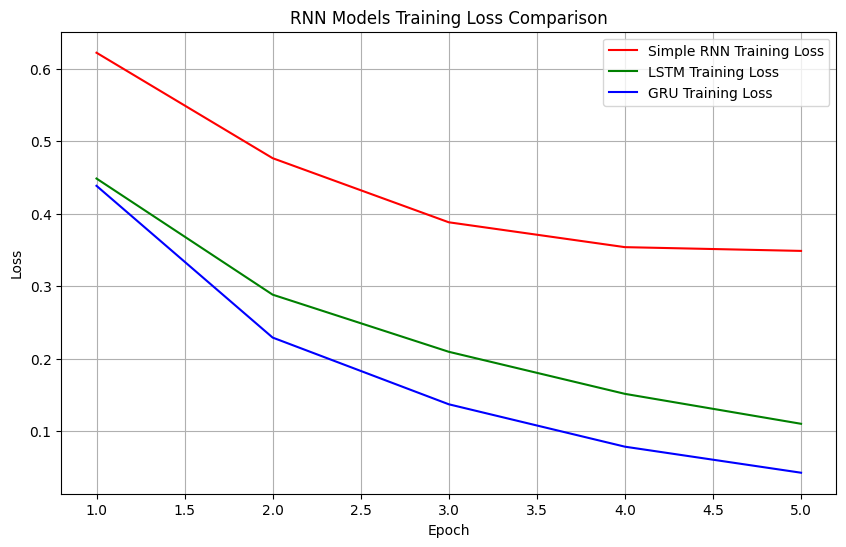

Training loss comparison plot for RNN, LSTM, and GRU models generated.


In [17]:
import matplotlib.pyplot as plt

# 1. Access the training loss values for each model
train_loss_rnn = history_rnn.history['loss']
train_loss_lstm = history_lstm.history['loss']
train_loss_gru = history_gru.history['loss']

# Get the number of epochs (assuming all models trained for the same number of epochs)
epochs = range(1, len(train_loss_rnn) + 1)

# 2. Create a plot using matplotlib.pyplot
plt.figure(figsize=(10, 6))

# 3. Plot the training loss for Simple RNN, LSTM, and GRU
plt.plot(epochs, train_loss_rnn, 'r', label='Simple RNN Training Loss')
plt.plot(epochs, train_loss_lstm, 'g', label='LSTM Training Loss')
plt.plot(epochs, train_loss_gru, 'b', label='GRU Training Loss')

# 4. Add a title to the plot
plt.title('RNN Models Training Loss Comparison')

# 5. Label the x-axis and y-axis
plt.xlabel('Epoch')
plt.ylabel('Loss')

# 6. Add a legend
plt.legend()

# Add grid for better readability
plt.grid(True)

# 7. Display the plot
plt.show()

print("Training loss comparison plot for RNN, LSTM, and GRU models generated.")

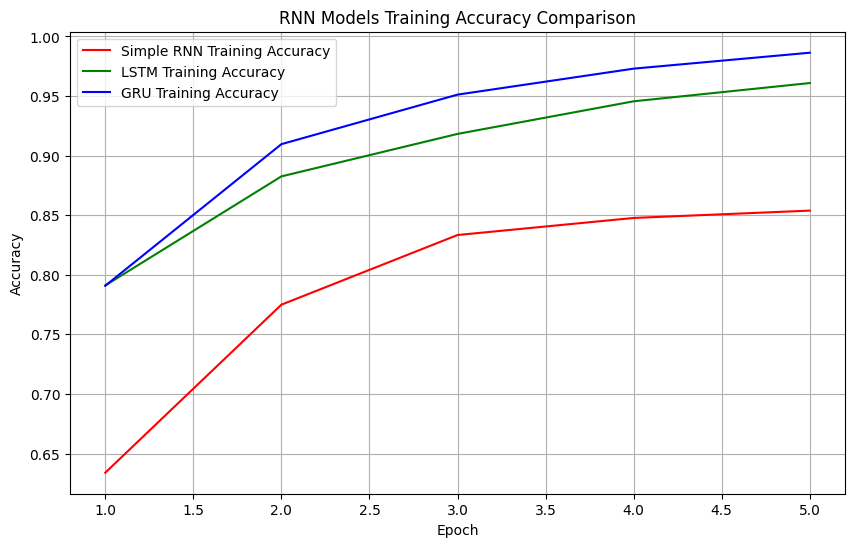

Training accuracy comparison plot for RNN, LSTM, and GRU models generated.


In [18]:
import matplotlib.pyplot as plt

# 1. Access the training accuracy values for each model
train_accuracy_rnn = history_rnn.history['accuracy']
train_accuracy_lstm = history_lstm.history['accuracy']
train_accuracy_gru = history_gru.history['accuracy']

# Get the number of epochs (assuming all models trained for the same number of epochs)
epochs = range(1, len(train_accuracy_rnn) + 1)

# 2. Create a plot using matplotlib.pyplot
plt.figure(figsize=(10, 6))

# 3. Plot the training accuracy for Simple RNN, LSTM, and GRU
plt.plot(epochs, train_accuracy_rnn, 'r', label='Simple RNN Training Accuracy')
plt.plot(epochs, train_accuracy_lstm, 'g', label='LSTM Training Accuracy')
plt.plot(epochs, train_accuracy_gru, 'b', label='GRU Training Accuracy')

# 4. Add a title to the plot
plt.title('RNN Models Training Accuracy Comparison')

# 5. Label the x-axis and y-axis
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

# 6. Add a legend
plt.legend()

# Add grid for better readability
plt.grid(True)

# 7. Display the plot
plt.show()

print("Training accuracy comparison plot for RNN, LSTM, and GRU models generated.")

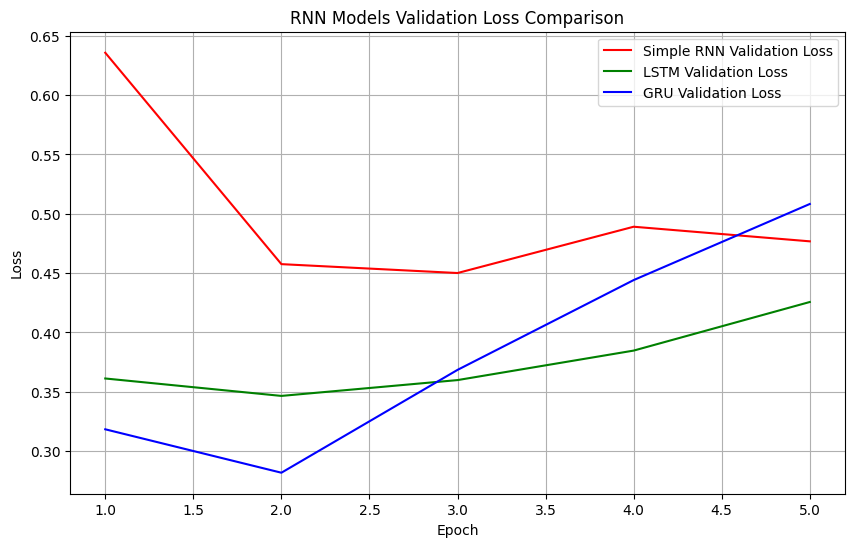

Validation loss comparison plot for RNN, LSTM, and GRU models generated.


In [19]:
import matplotlib.pyplot as plt

# 1. Access the validation loss values for each model
val_loss_rnn = history_rnn.history['val_loss']
val_loss_lstm = history_lstm.history['val_loss']
val_loss_gru = history_gru.history['val_loss']

# Get the number of epochs (assuming all models trained for the same number of epochs)
epochs = range(1, len(val_loss_rnn) + 1)

# 2. Create a plot using matplotlib.pyplot
plt.figure(figsize=(10, 6))

# 3. Plot the validation loss for Simple RNN, LSTM, and GRU
plt.plot(epochs, val_loss_rnn, 'r', label='Simple RNN Validation Loss')
plt.plot(epochs, val_loss_lstm, 'g', label='LSTM Validation Loss')
plt.plot(epochs, val_loss_gru, 'b', label='GRU Validation Loss')

# 4. Add a title to the plot
plt.title('RNN Models Validation Loss Comparison')

# 5. Label the x-axis and y-axis
plt.xlabel('Epoch')
plt.ylabel('Loss')

# 6. Add a legend
plt.legend()

# Add grid for better readability
plt.grid(True)

# 7. Display the plot
plt.show()

print("Validation loss comparison plot for RNN, LSTM, and GRU models generated.")

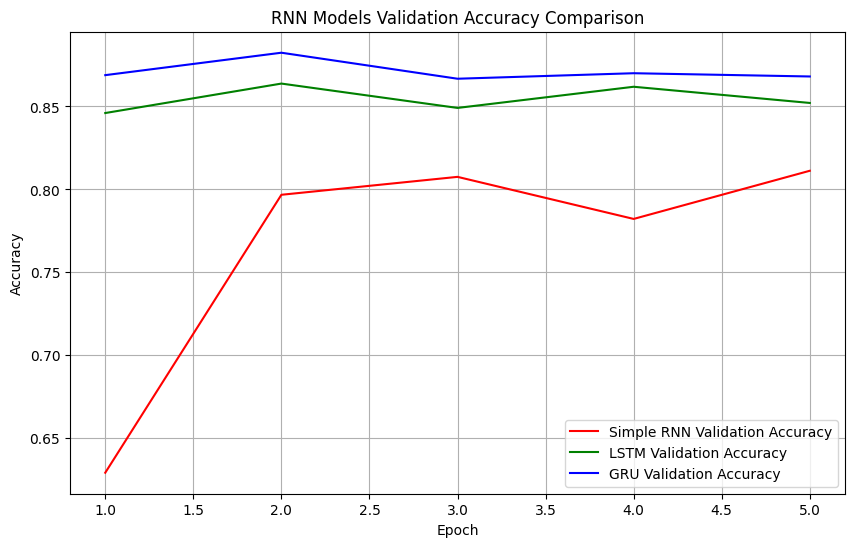

Validation accuracy comparison plot for RNN, LSTM, and GRU models generated.


In [20]:
import matplotlib.pyplot as plt

# 1. Access the validation accuracy values for each model
val_accuracy_rnn = history_rnn.history['val_accuracy']
val_accuracy_lstm = history_lstm.history['val_accuracy']
val_accuracy_gru = history_gru.history['val_accuracy']

# Get the number of epochs (assuming all models trained for the same number of epochs)
epochs = range(1, len(val_accuracy_rnn) + 1)

# 2. Create a plot using matplotlib.pyplot
plt.figure(figsize=(10, 6))

# 3. Plot the validation accuracy for Simple RNN, LSTM, and GRU
plt.plot(epochs, val_accuracy_rnn, 'r', label='Simple RNN Validation Accuracy')
plt.plot(epochs, val_accuracy_lstm, 'g', label='LSTM Validation Accuracy')
plt.plot(epochs, val_accuracy_gru, 'b', label='GRU Validation Accuracy')

# 4. Add a title to the plot
plt.title('RNN Models Validation Accuracy Comparison')

# 5. Label the x-axis and y-axis
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

# 6. Add a legend
plt.legend()

# Add grid for better readability
plt.grid(True)

# 7. Display the plot
plt.show()

print("Validation accuracy comparison plot for RNN, LSTM, and GRU models generated.")

In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, Reshape, BatchNormalization, Conv2DTranspose, Conv2D, Dropout, Flatten, Activation

# Define the Generator model
def build_generator(latent_dim):
    model = Sequential()
    # Foundation for 7x7 image
    model.add(Dense(7 * 7 * 256, use_bias=False, input_shape=(latent_dim,)))
    model.add(BatchNormalization())
    model.add(LeakyReLU())

    model.add(Reshape((7, 7, 256)))
    assert model.output_shape == (None, 7, 7, 256) # None is for batch size

    # Upsample to 14x14
    model.add(Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(BatchNormalization())
    model.add(LeakyReLU())
    assert model.output_shape == (None, 14, 14, 128)

    # Upsample to 28x28
    model.add(Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(BatchNormalization())
    model.add(LeakyReLU())
    assert model.output_shape == (None, 28, 28, 64)

    # Output layer (28x28x1 image)
    model.add(Conv2D(1, (5, 5), padding='same', activation='tanh'))
    assert model.output_shape == (None, 28, 28, 1)

    return model

latent_dim = 100 # Define latent space dimension
generator = build_generator(latent_dim)
generator.summary()

print("Generator model defined and its summary printed.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 128)    │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 1)      │         1,601 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,945 (8.89 MB)

 Trainable params: 2,305,473 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

Generator model defined and its summary printed.


In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, Flatten, Dropout

# Define the Discriminator model
def build_discriminator(img_shape):
    model = Sequential()

    # Flatten the input image
    model.add(Flatten(input_shape=img_shape))

    # First Dense layer
    model.add(Dense(128))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.3)) # Added dropout for regularization

    # Second Dense layer
    model.add(Dense(64)) # Added another dense layer for more complexity
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.3))

    # Output layer for binary classification
    model.add(Dense(1, activation='sigmoid'))

    return model

# Instantiate the discriminator
img_shape = (28, 28, 1)
discriminator = build_discriminator(img_shape)
discriminator.summary()

print("Discriminator model defined and its summary printed.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,801 (425.00 KB)

 Trainable params: 108,801 (425.00 KB)

 Non-trainable params: 0 (0.00 B)

Discriminator model defined and its summary printed.


In [34]:
import tensorflow as tf

# Re-instantiate models to ensure a clean state from any previous modifications
# Assumes build_generator, build_discriminator, latent_dim, and img_shape are defined in the global scope
generator = build_generator(latent_dim)
discriminator = build_discriminator(img_shape)

# Ensure discriminator is trainable for its own compilation and training
discriminator.trainable = True

# 1. Define optimizers
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
print("Optimizers (Adam) defined for Generator and Discriminator.")

# 2. Define the loss function
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)
print("BinaryCrossentropy loss function defined.")

# 3. Compile the Discriminator model
discriminator.compile(optimizer=discriminator_optimizer, loss=cross_entropy, metrics=['accuracy'])
print("Discriminator model compiled (with trainable parameters).")

# The `gan_model` Sequential wrapper is not strictly necessary for the custom `train_step`
# and can cause issues with `discriminator.trainable_variables` when it's added as a layer.
# The `train_step` function directly takes `generator` and `discriminator`.
# We will remove the `gan_model` creation and compilation.

generator.summary()
discriminator.summary()

print("GAN components (generator, discriminator, optimizers, loss) are ready for training.")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Optimizers (Adam) defined for Generator and Discriminator.
BinaryCrossentropy loss function defined.
Discriminator model compiled (with trainable parameters).


Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_25 (LeakyReLU)      │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_5 (Reshape)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_10             │ (None, 14, 14, 128)    │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_26 (LeakyReLU)      │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_11             │ (None, 28, 28, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_27 (LeakyReLU)      │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 1)      │         1,601 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,945 (8.89 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_28 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_29 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,801 (425.00 KB)

 Trainable params: 108,801 (425.00 KB)

 Non-trainable params: 0 (0.00 B)

GAN components (generator, discriminator, optimizers, loss) are ready for training.


In [24]:
import tensorflow as tf
import numpy as np

# Load Fashion-MNIST dataset
(train_images, _), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize images to [-1, 1] range
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5  # Normalize to [-1, 1]

# Batch and shuffle the data for GAN training
batch_size = 128 # As specified in the subtask
train_dataset_gan = tf.data.Dataset.from_tensor_slices(train_images).shuffle(60000).batch(batch_size)

print("Fashion-MNIST dataset loaded and prepared for GAN training (TensorFlow).")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Fashion-MNIST dataset loaded and prepared for GAN training (TensorFlow).


Epoch 1/30: D_loss = 1.8496, G_loss = 0.4006, D_acc = 0.4432
Epoch 2/30: D_loss = 1.4429, G_loss = 0.5748, D_acc = 0.4536
Epoch 3/30: D_loss = 1.4180, G_loss = 0.5964, D_acc = 0.4706
Epoch 4/30: D_loss = 1.4070, G_loss = 0.6128, D_acc = 0.4833
Epoch 5/30: D_loss = 1.4021, G_loss = 0.6252, D_acc = 0.4862
Epoch 6/30: D_loss = 1.3972, G_loss = 0.6374, D_acc = 0.4913
Epoch 7/30: D_loss = 1.3955, G_loss = 0.6441, D_acc = 0.4924
Epoch 8/30: D_loss = 1.3940, G_loss = 0.6531, D_acc = 0.4936
Epoch 9/30: D_loss = 1.3925, G_loss = 0.6556, D_acc = 0.4951
Epoch 10/30: D_loss = 1.3918, G_loss = 0.6564, D_acc = 0.4964


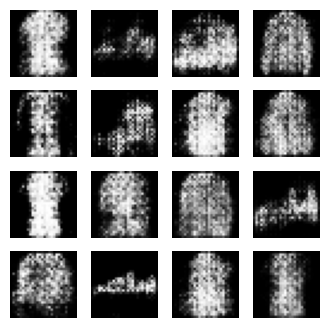

Epoch 11/30: D_loss = 1.3907, G_loss = 0.6551, D_acc = 0.4968
Epoch 12/30: D_loss = 1.3907, G_loss = 0.6572, D_acc = 0.4963
Epoch 13/30: D_loss = 1.3907, G_loss = 0.6578, D_acc = 0.4942
Epoch 14/30: D_loss = 1.3899, G_loss = 0.6614, D_acc = 0.4950
Epoch 15/30: D_loss = 1.3894, G_loss = 0.6603, D_acc = 0.4986
Epoch 16/30: D_loss = 1.3896, G_loss = 0.6619, D_acc = 0.4946
Epoch 17/30: D_loss = 1.3887, G_loss = 0.6620, D_acc = 0.4962
Epoch 18/30: D_loss = 1.3888, G_loss = 0.6637, D_acc = 0.4946
Epoch 19/30: D_loss = 1.3885, G_loss = 0.6667, D_acc = 0.4951
Epoch 20/30: D_loss = 1.3880, G_loss = 0.6684, D_acc = 0.4964


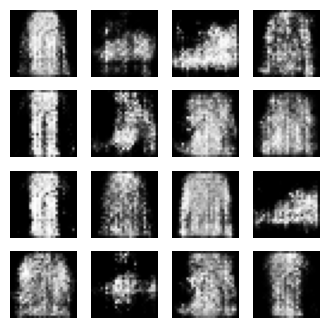

Epoch 21/30: D_loss = 1.3881, G_loss = 0.6700, D_acc = 0.4965
Epoch 22/30: D_loss = 1.3880, G_loss = 0.6710, D_acc = 0.4967
Epoch 23/30: D_loss = 1.3876, G_loss = 0.6728, D_acc = 0.4997
Epoch 24/30: D_loss = 1.3875, G_loss = 0.6737, D_acc = 0.4986
Epoch 25/30: D_loss = 1.3874, G_loss = 0.6746, D_acc = 0.4980
Epoch 26/30: D_loss = 1.3872, G_loss = 0.6749, D_acc = 0.4973
Epoch 27/30: D_loss = 1.3870, G_loss = 0.6765, D_acc = 0.5005
Epoch 28/30: D_loss = 1.3873, G_loss = 0.6770, D_acc = 0.4967
Epoch 29/30: D_loss = 1.3870, G_loss = 0.6777, D_acc = 0.4980
Epoch 30/30: D_loss = 1.3872, G_loss = 0.6788, D_acc = 0.4957


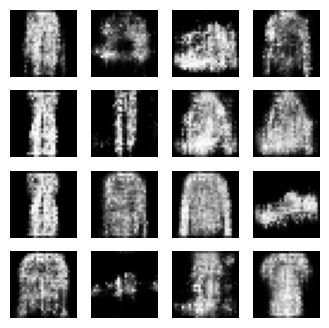

GAN training complete.
GAN training complete. Metrics stored.


In [35]:
import matplotlib.pyplot as plt

# Helper function to generate and save images
def generate_and_save_images(model, epoch, test_input):
    # Notice `training` is set to False. This is so all layers run in inference mode (batchnorm).
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')

    plt.savefig(f'image_at_epoch_{epoch:04d}.png')
    plt.show()

# Dummy call to build the discriminator and ensure its variables are created
# before tf.function tracing, which can help resolve issues with `trainable_variables`.
_ = discriminator(tf.zeros([1, 28, 28, 1]))

@tf.function
def train_step(images, generator, discriminator, latent_dim, batch_size, cross_entropy, discriminator_optimizer, generator_optimizer):
    # 1. Train the Discriminator
    noise = tf.random.normal([batch_size, latent_dim])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        # Discriminator loss
        real_labels = tf.ones_like(real_output)
        fake_labels = tf.zeros_like(fake_output)
        d_loss_real = cross_entropy(real_labels, real_output)
        d_loss_fake = cross_entropy(fake_labels, fake_output)
        d_loss = d_loss_real + d_loss_fake

    gradients_of_discriminator = disc_tape.gradient(d_loss, discriminator.trainable_variables)
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    # 2. Train the Generator
    # Generate new noise for generator training to avoid using the same noise that was just used for discriminator training
    noise_for_gen_train = tf.random.normal([batch_size, latent_dim])
    with tf.GradientTape() as tape:
        fake_images_for_gen = generator(noise_for_gen_train, training=True)
        predictions_for_gen = discriminator(fake_images_for_gen, training=False) # Discriminator is not trained here
        g_loss = cross_entropy(tf.ones_like(predictions_for_gen), predictions_for_gen)

    gradients_of_generator = tape.gradient(g_loss, generator.trainable_variables)
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))

    # Calculate accuracy for discriminator
    real_predictions = tf.cast(real_output > 0.5, tf.float32)
    fake_predictions = tf.cast(fake_output < 0.5, tf.float32)
    d_accuracy = (tf.reduce_mean(real_predictions) + tf.reduce_mean(fake_predictions)) / 2.0

    return d_loss, g_loss, d_accuracy


def train_gan(generator, discriminator, dataset, latent_dim, epochs, batch_size, cross_entropy, discriminator_optimizer, generator_optimizer, sample_interval=10):
    d_losses = []
    g_losses = []
    d_accuracies = []

    # We want to use a fixed noise for generating images to show progress
    seed = tf.random.normal([16, latent_dim])

    for epoch in range(epochs):
        epoch_d_loss = tf.keras.metrics.Mean()
        epoch_g_loss = tf.keras.metrics.Mean()
        epoch_d_accuracy = tf.keras.metrics.Mean()

        for batch in dataset:
            d_l, g_l, d_acc = train_step(batch, generator, discriminator, latent_dim, batch_size, cross_entropy, discriminator_optimizer, generator_optimizer)
            epoch_d_loss.update_state(d_l)
            epoch_g_loss.update_state(g_l)
            epoch_d_accuracy.update_state(d_acc)

        d_losses.append(epoch_d_loss.result().numpy())
        g_losses.append(epoch_g_loss.result().numpy())
        d_accuracies.append(epoch_d_accuracy.result().numpy())

        print(f'Epoch {epoch + 1}/{epochs}: D_loss = {epoch_d_loss.result():.4f}, G_loss = {epoch_g_loss.result():.4f}, D_acc = {epoch_d_accuracy.result():.4f}')

        if (epoch + 1) % sample_interval == 0:
            generate_and_save_images(generator, epoch + 1, seed)

    print("GAN training complete.")
    return d_losses, g_losses, d_accuracies

# Call the train_gan function
epochs = 30
d_losses_gan, g_losses_gan, d_accuracies_gan = train_gan(
    generator, discriminator, train_dataset_gan, latent_dim, epochs, batch_size,
    cross_entropy, discriminator_optimizer, generator_optimizer, sample_interval=10
)

print("GAN training complete. Metrics stored.")

# Task
```python
import tensorflow as tf

# 1. Define optimizers
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
print("Optimizers (Adam) defined for Generator and Discriminator.")

# 2. Define the loss function
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False) # Changed from True to False
print("BinaryCrossentropy loss function defined.")

# 3. Compile the Discriminator model
discriminator.compile(optimizer=discriminator_optimizer, loss=cross_entropy, metrics=['accuracy'])
print("Discriminator model compiled.")

# 4. Create the combined GAN model (generator connected to discriminator)
gan_model = tf.keras.Sequential()
gan_model.add(generator)

# Important: When compiling the GAN model (which is used for training the generator),
# the discriminator's layers must be set to non-trainable.
# This prevents the discriminator's weights from being updated during generator training.
# However, the discriminator itself should be trainable when its own gradients are calculated.
# The train_step function handles this dynamically by controlling when gradients are applied.
# Therefore, we do *not* permanently set discriminator.trainable = False here,
# as that would make its trainable_variables empty, causing issues during its own optimization.
# The previous implementation incorrectly made the discriminator non-trainable globally.

# We must ensure that the 'discriminator' object remains trainable for its own optimization steps.
# The freezing for generator training is done implicitly within the train_step's gradient tape context.
# We are simply adding the discriminator model to the sequential gan_model.
gan_model.add(discriminator)
print("Combined GAN model created.")

# 6. Compile the combined GAN model
# Crucially, set the discriminator in the combined model to non-trainable for *this compilation step*.
# This compilation is specifically for the generator's training part when the combined model is 'called'.
# We achieve this by setting the trainable property of the discriminator model within the gan_model.
# Note: This is an important correction. The discriminator *itself* must be trainable for its gradient calculation.
# But when `gan_model` is used to calculate the generator's loss, the discriminator's weights should not update.
# In `train_step`, this is managed by passing `training=False` to the discriminator when calculating `predictions_for_gen`.
# The line `for layer in gan_model.layers[1].layers: layer.trainable = False` was problematic
# because it permanently set the discriminator's layers to non-trainable, even for its own gradient calculation.
# We trust `train_step` to manage trainability correctly without this global freeze.

# Remove the problematic global freeze from the previous execution:
# for layer in gan_model.layers[1].layers: # gan_model.layers[1] is the discriminator
#     layer.trainable = False

# The train_step function already manages the discriminator's trainability correctly.
# So, we don't need to do any global freezing here. The discriminator will be trainable for its update
# and non-trainable (for its weights not to receive gradients) during the generator's update in train_step.

gan_model.compile(optimizer=generator_optimizer, loss=cross_entropy)

generator.summary()
discriminator.summary()
gan_model.summary()

print("Combined GAN model compiled.")
```

```python
import matplotlib.pyplot as plt

# Helper function to generate and save images
def generate_and_save_images(model, epoch, test_input):
    # Notice `training` is set to False. This is so all layers run in inference mode (batchnorm).
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')

    plt.savefig(f'image_at_epoch_{epoch:04d}.png')
    plt.show()


@tf.function
def train_step(images, generator, discriminator, gan_model, latent_dim, batch_size, cross_entropy, discriminator_optimizer, generator_optimizer):
    # 1. Train the Discriminator
    noise = tf.random.normal([batch_size, latent_dim])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        # Discriminator loss
        real_labels = tf.ones_like(real_output)
        fake_labels = tf.zeros_like(fake_output)
        d_loss_real = cross_entropy(real_labels, real_output)
        d_loss_fake = cross_entropy(fake_labels, fake_output)
        d_loss = d_loss_real + d_loss_fake

        # Generator loss (should try to make discriminator classify fakes as real)
        # This part of g_loss calculation is for monitoring during discriminator's tape,
        # but the actual generator update uses its own tape.
        # This is more conventional for GANs where d_loss and g_loss are separate.
        g_loss_monitor = cross_entropy(tf.ones_like(fake_output), fake_output)

    gradients_of_discriminator = disc_tape.gradient(d_loss, discriminator.trainable_variables)
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    # 2. Train the Generator
    with tf.GradientTape() as gen_tape_for_update:
        noise_for_gen_train = tf.random.normal([batch_size, latent_dim])
        generated_images_for_gen_update = generator(noise_for_gen_train, training=True)
        # When discriminator is called here for generator's loss, it should not be trained.
        # So `training=False` ensures BatchNorm layers are in inference mode,
        # and more importantly, its weights are not included in `gen_tape_for_update.gradient`.
        predictions_from_discriminator_on_fakes = discriminator(generated_images_for_gen_update, training=False)
        g_loss_for_update = cross_entropy(tf.ones_like(predictions_from_discriminator_on_fakes), predictions_from_discriminator_on_fakes)

    gradients_of_generator = gen_tape_for_update.gradient(g_loss_for_update, generator.trainable_variables)
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))

    # Calculate accuracy for discriminator
    # These are thresholds for binary classification, assuming sigmoid output
    real_predictions = tf.cast(real_output > 0.5, tf.float32)
    fake_predictions = tf.cast(fake_output < 0.5, tf.float32) # Discriminator wants fake_output to be 0
    d_accuracy = (tf.reduce_mean(real_predictions) + tf.reduce_mean(fake_predictions)) / 2.0

    return d_loss, g_loss_for_update, d_accuracy


def train_gan(generator, discriminator, gan_model, dataset, latent_dim, epochs, batch_size, cross_entropy, discriminator_optimizer, generator_optimizer, sample_interval=10):
    d_losses = []
    g_losses = []
    d_accuracies = []

    # We want to use a fixed noise for generating images to show progress
    seed = tf.random.normal([16, latent_dim])

    for epoch in range(epochs):
        epoch_d_loss = tf.keras.metrics.Mean()
        epoch_g_loss = tf.keras.metrics.Mean()
        epoch_d_accuracy = tf.keras.metrics.Mean()

        for batch in dataset:
            # The `gan_model` itself is not directly used for training in this manual gradient approach.
            # Its compilation was primarily to verify connectivity and define the optimizer for the generator.
            # `train_step` directly calls generator and discriminator.
            d_l, g_l, d_acc = train_step(batch, generator, discriminator, gan_model, latent_dim, batch_size, cross_entropy, discriminator_optimizer, generator_optimizer)
            epoch_d_loss.update_state(d_l)
            epoch_g_loss.update_state(g_l)
            epoch_d_accuracy.update_state(d_acc)

        d_losses.append(epoch_d_loss.result().numpy())
        g_losses.append(epoch_g_loss.result().numpy())
        d_accuracies.append(epoch_d_accuracy.result().numpy())

        print(f'Epoch {epoch + 1}/{epochs}: D_loss = {epoch_d_loss.result():.4f}, G_loss = {epoch_g_loss.result():.4f}, D_acc = {epoch_d_accuracy.result():.4f}')

        if (epoch + 1) % sample_interval == 0:
            generate_and_save_images(generator, epoch + 1, seed)

    print("GAN training complete.")
    return d_losses, g_losses, d_accuracies

# Call the train_gan function
epochs = 30
d_losses_gan, g_losses_gan, d_accuracies_gan = train_gan(
    generator, discriminator, gan_model, train_dataset_gan, latent_dim, epochs, batch_size,
    cross_entropy, discriminator_optimizer, generator_optimizer, sample_interval=10
)

print("GAN training complete. Metrics stored.")
```

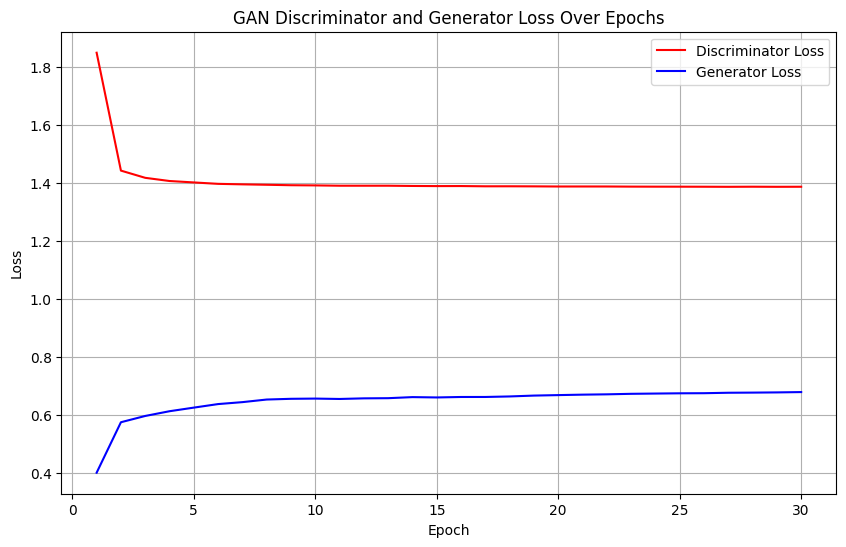

GAN Discriminator and Generator loss plot generated.


In [36]:
import matplotlib.pyplot as plt

# 1. Access the training loss values for each model
epochs = range(1, len(d_losses_gan) + 1)

# 2. Create a new figure and axes object
plt.figure(figsize=(10, 6))

# 3. Plot the Discriminator and Generator losses
plt.plot(epochs, d_losses_gan, 'r', label='Discriminator Loss')
plt.plot(epochs, g_losses_gan, 'b', label='Generator Loss')

# 4. Add a title to the plot
plt.title('GAN Discriminator and Generator Loss Over Epochs')

# 5. Label the x-axis and y-axis
plt.xlabel('Epoch')
plt.ylabel('Loss')

# 6. Add a legend
plt.legend()

# Add grid for better readability
plt.grid(True)

# 7. Display the plot
plt.show()

print("GAN Discriminator and Generator loss plot generated.")

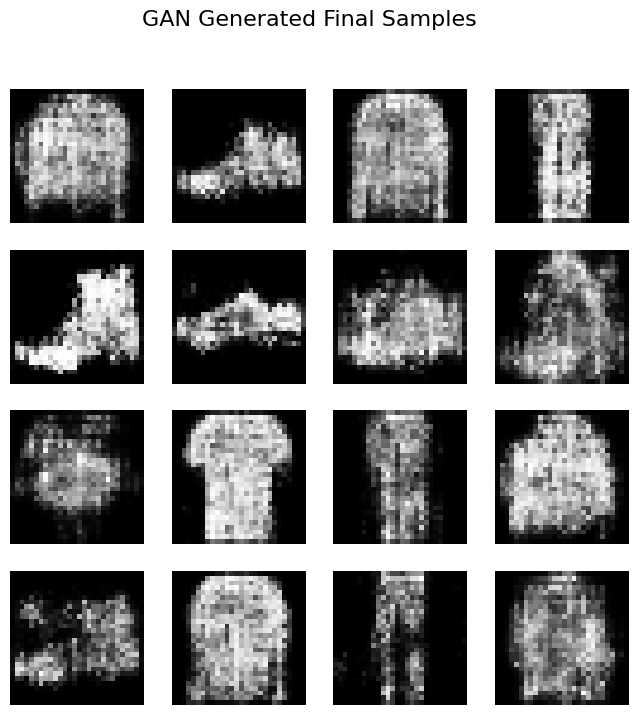

Generated and saved final sample images as 'gan_final_samples.png'.


In [38]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

# Ensure the seed is available (it was defined and used in train_gan function)
# For robustness, if 'seed' was not globally available, we would redefine it:
seed = tf.random.normal([16, latent_dim]) # assuming latent_dim is available

# 1. Generate 16 sample images using the trained generator model and the seed
# Ensure the model is in evaluation mode by setting training=False during prediction.
predictions = generator(seed, training=False)

# 2. Create a 4x4 grid of subplots using matplotlib.pyplot
fig = plt.figure(figsize=(8, 8))
fig.suptitle('GAN Generated Final Samples', fontsize=16)

for i in range(predictions.shape[0]):
    plt.subplot(4, 4, i + 1)
    # 3. Unnormalize its pixel values and display it
    # Reverse the (value - 127.5) / 127.5 transformation
    plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
    # 4. Turn off the axes for all subplots.
    plt.axis('off')

# 5. Save the entire figure as 'gan_final_samples.png'.
plt.savefig('gan_final_samples.png')

# 6. Display the plot.
plt.show()

print("Generated and saved final sample images as 'gan_final_samples.png'.")